In [4]:
!pip -q install pandas numpy matplotlib scipy statsmodels pillow

import os
import math
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
from PIL import Image, ImageOps, ImageDraw, ImageFont

from google.colab import files

OUTPUT_DIR = "/content/faers_acetaminophen_aspirin_caffeine"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BURGUNDY = "#7A1F2B"
DEEP_RED = "#5C1620"
MID_RED = "#A64B57"
LIGHT_RED = "#D9A0A7"
PALE_RED = "#EAD0D3"
GRAY = "#B7B7B7"

# Colab 한글 폰트 설치
!apt-get -qq update
!apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("환경 설정 완료")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
환경 설정 완료


In [5]:
df = pd.read_csv("/content/아세트아미노펜_51개브랜드_전체행_최종.csv", encoding="utf-8")

print("원본 데이터 크기:", df.shape)
display(df.head(3))

required_columns = [
    "report_id", "serious", "is_fatal", "is_hospitalized",
    "is_life_threat", "is_disabling", "reactions",
    "num_drugs", "drug_count_category", "patient_age_years",
    "age_group", "patient_sex", "drug_indication",
    "brand_name", "전체_활성성분"
]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise KeyError(f"필수 컬럼이 없습니다: {missing}")

print("report_id 중복 수:", df["report_id"].duplicated().sum())


원본 데이터 크기: (1248, 39)


,report_id,receive_date,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,is_disabling,reactions,...,참조_영문성분명,참조_국문성분명,참조_정보수준,참조_최대용량_기간제한,참조_절대금기(do_not_use),참조_즉시중단_신호(stop_use),참조_임부_수유부_주의,참조_기타주의사항,매칭된_브랜드명,전체_활성성분
0,10019350,2015-02-24,2015Q1,Yes,Death; Hospitalization,True,True,False,False,Overdose; Multi-organ failure; Hepatic failure,...,Acetaminophen (Paracetamol),아세트아미노펜,FDA라벨 상세조회,24시간 내 4000mg 초과 금지(간손상 위험). 이 라벨 기준 1회 2정(100...,다른 아세트아미노펜 함유 제품(처방/비처방 불문)과 동시 복용 절대 금지 - 성분 ...,"새로운 증상 발생, 통증 10일↑ 또는 발열 3일↑ 지속, 발적/부종 발생 시 중단...",임신/수유 중 사용 전 의료진 상담,음주 하루 3잔↑ 하면서 복용 시 간손상 위험 증가. 과다복용 시 무증상이어도 즉시...,TYLENOL COLD PLUS HEAD CONGESTION SEVERE; TYLE...,TYLENOL COLD PLUS HEAD CONGESTION SEVERE: Acet...
1,10019352,2015-02-24,2015Q1,Yes,Hospitalization,False,True,False,False,Overdose; Toxicity to various agents,...,Acetaminophen (Paracetamol),아세트아미노펜,FDA라벨 상세조회,24시간 내 4000mg 초과 금지(간손상 위험). 이 라벨 기준 1회 2정(100...,다른 아세트아미노펜 함유 제품(처방/비처방 불문)과 동시 복용 절대 금지 - 성분 ...,"새로운 증상 발생, 통증 10일↑ 또는 발열 3일↑ 지속, 발적/부종 발생 시 중단...",임신/수유 중 사용 전 의료진 상담,음주 하루 3잔↑ 하면서 복용 시 간손상 위험 증가. 과다복용 시 무증상이어도 즉시...,AMAZON BASIC CARE ACETAMINOPHEN; PAIN RELIEF; ...,AMAZON BASIC CARE ACETAMINOPHEN: Acetaminophen...
2,10083990,2015-02-24,2015Q1,Yes,Death; Hospitalization,True,True,False,False,Overdose; Intestinal ischaemia; Renal failure;...,...,Acetaminophen (Paracetamol),아세트아미노펜,FDA라벨 상세조회,24시간 내 4000mg 초과 금지(간손상 위험). 이 라벨 기준 1회 2정(100...,다른 아세트아미노펜 함유 제품(처방/비처방 불문)과 동시 복용 절대 금지 - 성분 ...,"새로운 증상 발생, 통증 10일↑ 또는 발열 3일↑ 지속, 발적/부종 발생 시 중단...",임신/수유 중 사용 전 의료진 상담,음주 하루 3잔↑ 하면서 복용 시 간손상 위험 증가. 과다복용 시 무증상이어도 즉시...,TYLENOL EXTRA STRENGTH; TYLENOL EXTRA STRENGTH...,TYLENOL EXTRA STRENGTH: Acetaminophen; TYLENOL...


report_id 중복 수: 0


In [6]:
#아세트아미노펜 + 아스피린 + 카페인 조합 추출

TARGET_INGREDIENTS = {"acetaminophen", "aspirin", "caffeine"}

def parse_brand_ingredient_entries(value):
    # 전체_활성성분의 각 항목을 브랜드명과 성분 집합으로 분리
    if pd.isna(value):
        return []

    entries = []
    for part in [x.strip() for x in str(value).split(";") if x.strip()]:
        if ":" in part:
            brand, ingredient_text = part.split(":", 1)
        else:
            brand, ingredient_text = "", part

        ingredients = {
            x.strip().lower()
            for x in ingredient_text.split("+")
            if x.strip()
        }
        entries.append((brand.strip(), ingredients))

    return entries

def is_target_combination(value):
    # 정확히 세 성분으로만 구성된 항목이 하나라도 있으면 True
    return any(
        ingredients == TARGET_INGREDIENTS
        for _, ingredients in parse_brand_ingredient_entries(value)
    )

target_mask = df["전체_활성성분"].apply(is_target_combination)

target_df = df.loc[target_mask].copy()
other_df = df.loc[~target_mask].copy()

target_df = target_df.drop_duplicates(subset="report_id").reset_index(drop=True)
other_df = other_df.drop_duplicates(subset="report_id").reset_index(drop=True)

N = len(target_df)

print("대상 조합 고유 보고 수:", N)
print("그 외 아세트아미노펜 관련 보고 수:", len(other_df))

if N == 0:
    raise ValueError(
        "대상 성분조합이 추출되지 않았습니다. 전체_활성성분 형식을 확인해 주세요."
    )

display(
    target_df[
        ["report_id", "brand_name", "전체_활성성분", "serious", "reactions"]
    ].head()
)


대상 조합 고유 보고 수: 26
그 외 아세트아미노펜 관련 보고 수: 1222


,report_id,brand_name,전체_활성성분,serious,reactions
0,11157617,GOODYS EXTRA STRENGTH,GOODYS EXTRA STRENGTH: Aspirin + Acetaminophen...,Yes,Hypersensitivity; Stomatitis; Aphasia; Muscula...
1,11445158,EXCEDRIN MIGRAINE,EXCEDRIN MIGRAINE: Acetaminophen + Aspirin + C...,Yes,Crohn^s disease; Drug ineffective
2,10650219,EXCEDRIN MIGRAINE,EXCEDRIN MIGRAINE: Acetaminophen + Aspirin + C...,Yes,Cerebral artery occlusion; Speech disorder; Mi...
3,10970685,EXCEDRIN EXTRA STRENGTH GELTABS; EXCEDRIN EXTR...,EXCEDRIN EXTRA STRENGTH GELTABS: Acetaminophen...,Yes,Headache; Drug ineffective
4,10979192,EXCEDRIN EXTRA STRENGTH GELTABS; EXCEDRIN EXTR...,EXCEDRIN EXTRA STRENGTH GELTABS: Acetaminophen...,Yes,Drug ineffective; Gastrointestinal ulcer


In [7]:

#공통 전처리 함수 및 파생변수 생성

def as_bool(value):
    return str(value).strip().lower() in {"true", "yes", "1"}

def is_serious(value):
    return str(value).strip().lower() == "yes"

def split_terms(value):
    # 세미콜론으로 연결된 다중 값을 분리하고 한 보고 내 중복을 제거
    if pd.isna(value):
        return []

    return list({
        x.strip()
        for x in str(value).split(";")
        if x.strip() and x.strip().lower() != "nan"
    })

NONCLINICAL_TERMS = {
    "Drug ineffective",
    "Product quality issue",
    "Product complaint",
    "Product use issue",
    "Product tampering",
    "Product package associated injury",
    "Drug resistance",
    "Incorrect dose administered",
    "Intentional product misuse",
    "Off label use",
    "Product use in unapproved indication",
    "Wrong technique in product usage process",
    "Exposure during pregnancy",
}

def has_clinical_reaction(value):
    terms = set(split_terms(value))
    return bool(terms - NONCLINICAL_TERMS)

target_df["clinical_reaction_present"] = (
    target_df["reactions"].apply(has_clinical_reaction)
)

target_df["serious_bool"] = target_df["serious"].apply(is_serious)
target_df["fatal_bool"] = target_df["is_fatal"].apply(as_bool)
target_df["hospitalized_bool"] = target_df["is_hospitalized"].apply(as_bool)
target_df["life_threat_bool"] = target_df["is_life_threat"].apply(as_bool)
target_df["disabling_bool"] = target_df["is_disabling"].apply(as_bool)

target_df["num_drugs_num"] = pd.to_numeric(
    target_df["num_drugs"], errors="coerce"
)

display(
    target_df[
        ["serious_bool", "clinical_reaction_present", "num_drugs_num"]
    ].head()
)


,serious_bool,clinical_reaction_present,num_drugs_num
0,True,True,1
1,True,True,1
2,True,True,12
3,True,True,1
4,True,True,1


In [8]:
#중증도
severity_labels = ["중대", "사망", "입원", "생명위협", "후유장애"]
severity_counts = [
    int(target_df["serious_bool"].sum()),
    int(target_df["fatal_bool"].sum()),
    int(target_df["hospitalized_bool"].sum()),
    int(target_df["life_threat_bool"].sum()),
    int(target_df["disabling_bool"].sum()),
]
severity_pct = [count / N * 100 for count in severity_counts]

# 연령대
age_order = [
    "Infant(0-2)",
    "Child(3-12)",
    "Teen(13-18)",
    "Adult(19-40)",
    "Middle-Aged(41-65)",
    "Senior(66-80)",
    "Elderly(81+)",
    "Unknown",
]

age_labels_ko = [
    "영유아\n(0–2)",
    "아동\n(3–12)",
    "청소년\n(13–18)",
    "성인\n(19–40)",
    "중년\n(41–65)",
    "노년\n(66–80)",
    "고령\n(81+)",
    "미상",
]

age_counts = (
    target_df["age_group"]
    .fillna("Unknown")
    .value_counts()
    .reindex(age_order, fill_value=0)
)
age_pct = age_counts / N * 100

# 성별
sex_order = ["Female", "Male", "Unknown"]
sex_labels_ko = ["여성", "남성", "미상"]

sex_counts = (
    target_df["patient_sex"]
    .fillna("Unknown")
    .value_counts()
    .reindex(sex_order, fill_value=0)
)
sex_pct = sex_counts / N * 100

#병용약물 수
def make_drug_category(value):
    if pd.isna(value):
        return "Unknown"

    value = float(value)

    if value == 1:
        return "Single"
    if 2 <= value <= 3:
        return "2-3 Drugs"
    if 4 <= value <= 5:
        return "4-5 Drugs"
    if value >= 6:
        return "Polypharmacy(6+)"

    return "Unknown"

drug_category = target_df["drug_count_category"].copy()
empty_mask = (
    drug_category.isna()
    | drug_category.astype(str).str.strip().eq("")
)

drug_category.loc[empty_mask] = (
    target_df.loc[empty_mask, "num_drugs_num"]
    .apply(make_drug_category)
)

drug_order = [
    "Single",
    "2-3 Drugs",
    "4-5 Drugs",
    "Polypharmacy(6+)",
    "Unknown",
]
drug_labels_ko = ["단일", "2–3개", "4–5개", "다약제\n(6개+)", "미상"]

drug_counts = (
    drug_category
    .value_counts()
    .reindex(drug_order, fill_value=0)
)
drug_pct = drug_counts / N * 100

#적응증 Top5
indication_counter = Counter()

for value in target_df["drug_indication"]:
    for term in split_terms(value):
        indication_counter[term] += 1

indication_top5 = indication_counter.most_common(5)

# 보고 반응 Top8
reaction_counter = Counter()

for value in target_df["reactions"]:
    for term in split_terms(value):
        reaction_counter[term] += 1

reaction_top8 = reaction_counter.most_common(8)

print("중증도:", list(zip(severity_labels, severity_counts, severity_pct)))
print("적응증 Top5:", indication_top5)
print("보고 반응 Top8:", reaction_top8)


중증도: [('중대', 7, 26.923076923076923), ('사망', 0, 0.0), ('입원', 3, 11.538461538461538), ('생명위협', 0, 0.0), ('후유장애', 0, 0.0)]
적응증 Top5: [('Migraine', 13), ('Product Used For Unknown Indication', 5), ('Headache', 3), ('Unknown', 2), ('Pain', 2)]
보고 반응 Top8: [('Drug ineffective', 18), ('Product quality issue', 7), ('Headache', 5), ('Product complaint', 3), ('Product use issue', 2), ('Ulcer', 2), ('Aphasia', 1), ('Hypersensitivity', 1)]


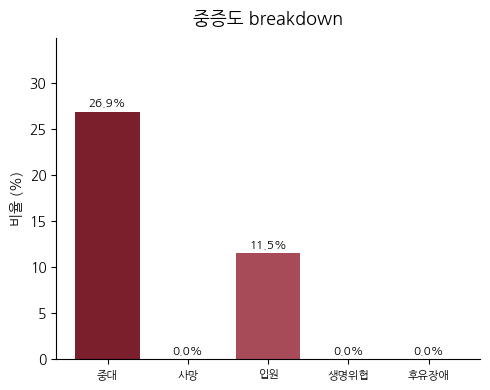

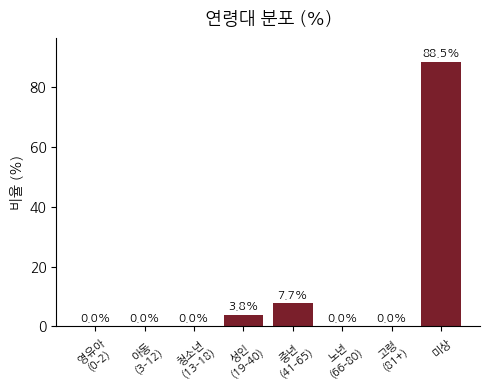

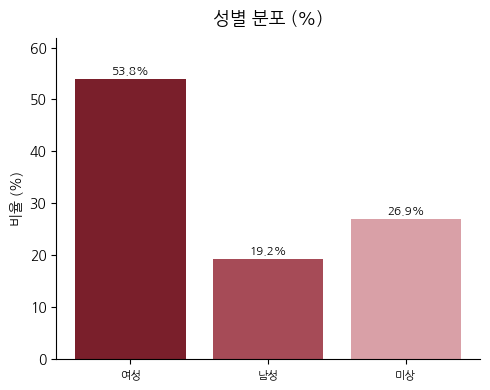

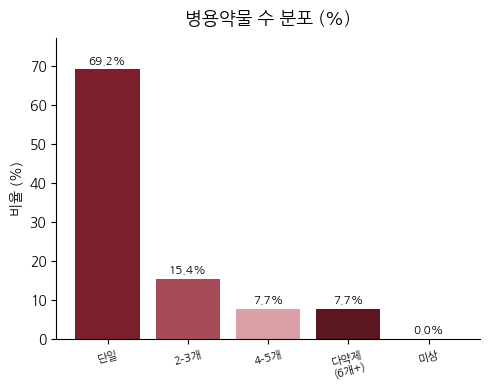

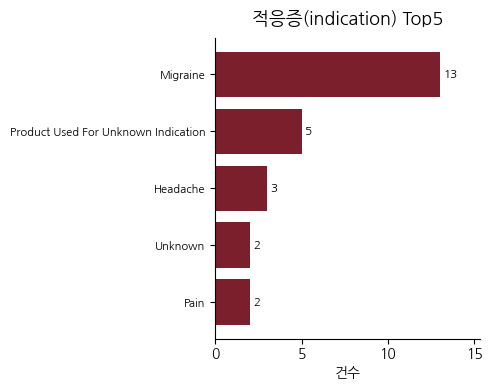

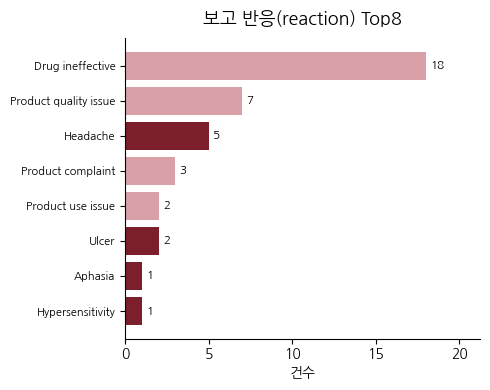

In [9]:
def save_vertical_bar(
    labels,
    values,
    title,
    filename,
    ylabel="비율 (%)",
    colors=None,
    rotate=0,
    ylim_pad=8,
):
    fig, ax = plt.subplots(figsize=(5, 4))

    if colors is None:
        colors = [BURGUNDY] * len(labels)

    bars = ax.bar(labels, values, color=colors)

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", rotation=rotate, labelsize=8)

    max_value = max(values) if len(values) else 0
    ax.set_ylim(0, max_value + ylim_pad)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + max(0.5, max_value * 0.02),
            f"{value:.1f}%",
            ha="center",
            fontsize=8.5,
        )

    plt.tight_layout()

    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    return path

def save_horizontal_bar(
    labels,
    values,
    title,
    filename,
    colors=None,
):
    fig, ax = plt.subplots(figsize=(5, 4))

    if colors is None:
        colors = [BURGUNDY] * len(labels)

    y = np.arange(len(labels))
    bars = ax.barh(y, values, color=colors)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("건수")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    max_value = max(values) if len(values) else 0
    ax.set_xlim(0, max_value + max(1.5, max_value * 0.18))

    for bar, value in zip(bars, values):
        ax.text(
            value + max(0.1, max_value * 0.015),
            bar.get_y() + bar.get_height() / 2,
            str(int(value)),
            va="center",
            fontsize=8.5,
        )

    plt.tight_layout()

    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    return path

chart_paths = []

chart_paths.append(
    save_vertical_bar(
        severity_labels,
        severity_pct,
        "중증도 breakdown",
        "01_중증도_breakdown.png",
        colors=[BURGUNDY, DEEP_RED, MID_RED, LIGHT_RED, PALE_RED],
    )
)

chart_paths.append(
    save_vertical_bar(
        age_labels_ko,
        age_pct.tolist(),
        "연령대 분포 (%)",
        "02_연령대_분포.png",
        rotate=40,
    )
)

chart_paths.append(
    save_vertical_bar(
        sex_labels_ko,
        sex_pct.tolist(),
        "성별 분포 (%)",
        "03_성별_분포.png",
        colors=[BURGUNDY, MID_RED, LIGHT_RED],
    )
)

chart_paths.append(
    save_vertical_bar(
        drug_labels_ko,
        drug_pct.tolist(),
        "병용약물 수 분포 (%)",
        "04_병용약물수_분포.png",
        colors=[BURGUNDY, MID_RED, LIGHT_RED, DEEP_RED, GRAY],
        rotate=15,
    )
)

indication_labels = [item[0] for item in indication_top5]
indication_values = [item[1] for item in indication_top5]

chart_paths.append(
    save_horizontal_bar(
        indication_labels,
        indication_values,
        "적응증(indication) Top5",
        "05_적응증_Top5.png",
    )
)

reaction_labels = [item[0] for item in reaction_top8]
reaction_values = [item[1] for item in reaction_top8]
reaction_colors = [
    LIGHT_RED if label in NONCLINICAL_TERMS else BURGUNDY
    for label in reaction_labels
]

chart_paths.append(
    save_horizontal_bar(
        reaction_labels,
        reaction_values,
        "보고 반응(reaction) Top8",
        "06_보고반응_Top8.png",
        colors=reaction_colors,
    )
)


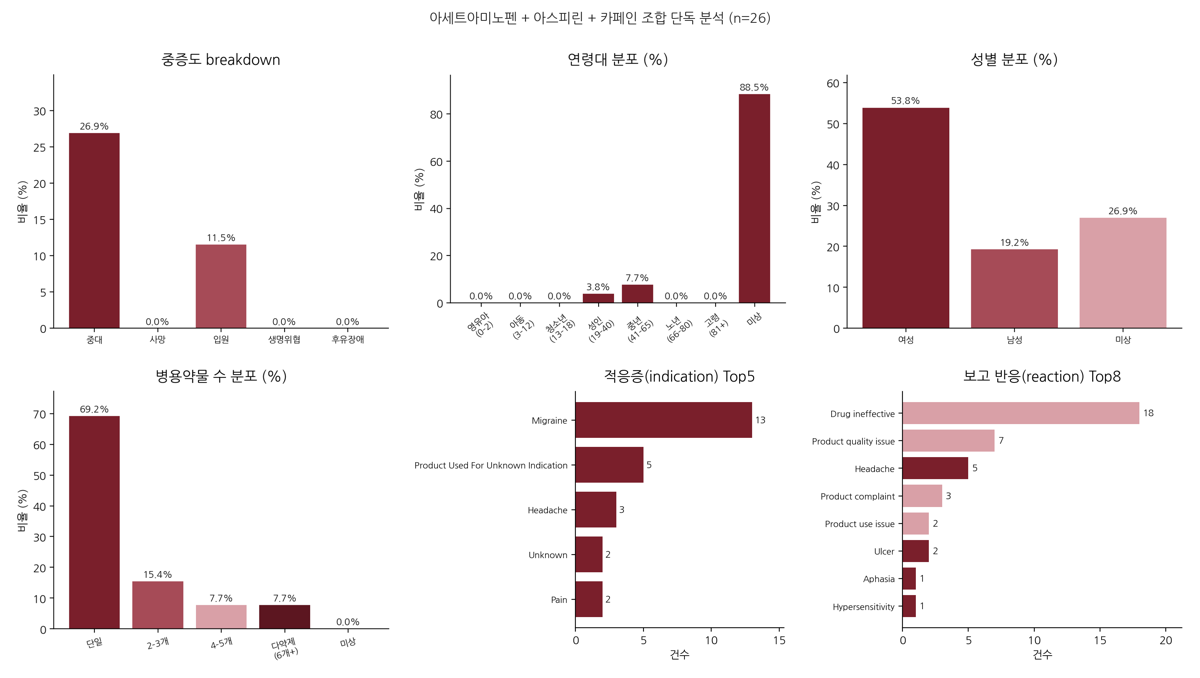

저장 위치: /content/faers_acetaminophen_aspirin_caffeine/아세트아미노펜_아스피린_카페인_6패널_분석.png


In [10]:
images = [Image.open(path).convert("RGB") for path in chart_paths]

cell_width = max(image.width for image in images)
cell_height = max(image.height for image in images)
margin = 25
title_height = 90

canvas_width = cell_width * 3 + margin * 4
canvas_height = cell_height * 2 + margin * 3 + title_height

canvas = Image.new(
    "RGB",
    (canvas_width, canvas_height),
    "white",
)

draw = ImageDraw.Draw(canvas)

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
title_font = ImageFont.truetype(font_path, 34)

dashboard_title = (
    f"아세트아미노펜 + 아스피린 + 카페인 조합 단독 분석 (n={N})"
)

bbox = draw.textbbox((0, 0), dashboard_title, font=title_font)

draw.text(
    ((canvas_width - (bbox[2] - bbox[0])) / 2, 25),
    dashboard_title,
    fill="#222222",
    font=title_font,
)

positions = []

for row in range(2):
    for col in range(3):
        x = margin + col * (cell_width + margin)
        y = title_height + margin + row * (cell_height + margin)
        positions.append((x, y))

for image, position in zip(images, positions):
    padded = ImageOps.pad(
        image,
        (cell_width, cell_height),
        color="white",
    )
    canvas.paste(padded, position)

dashboard_path = os.path.join(
    OUTPUT_DIR,
    "아세트아미노펜_아스피린_카페인_6패널_분석.png",
)

canvas.save(dashboard_path)

display(
    canvas.resize(
        (1200, int(1200 * canvas.height / canvas.width))
    )
)

print("저장 위치:", dashboard_path)


In [11]:
def wilson_ci(successes, total, alpha=0.05):
    if total == 0:
        return np.nan, np.nan

    low, high = proportion_confint(
        count=successes,
        nobs=total,
        alpha=alpha,
        method="wilson",
    )

    return float(low), float(high)

severity_summary = []

for label, count in zip(severity_labels, severity_counts):
    low, high = wilson_ci(count, N)

    severity_summary.append({
        "항목": label,
        "건수": count,
        "전체건수": N,
        "비율": count / N,
        "Wilson_95CI_하한": low,
        "Wilson_95CI_상한": high,
    })

severity_summary_df = pd.DataFrame(severity_summary)

display(
    severity_summary_df.style.format({
        "비율": "{:.1%}",
        "Wilson_95CI_하한": "{:.1%}",
        "Wilson_95CI_상한": "{:.1%}",
    })
)

severity_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "중증도_Wilson_신뢰구간.csv"),
    index=False,
    encoding="utf-8-sig",
)


,항목,건수,전체건수,비율,Wilson_95CI_하한,Wilson_95CI_상한
0,중대,7,26,26.9%,13.7%,46.1%
1,사망,0,26,0.0%,0.0%,12.9%
2,입원,3,26,11.5%,4.0%,29.0%
3,생명위협,0,26,0.0%,0.0%,12.9%
4,후유장애,0,26,0.0%,0.0%,12.9%


In [12]:

def corrected_or_ci(a, b, c, d):
    # 0 셀 문제를 줄이기 위해 각 셀에 0.5를 더한 보정 OR/CI
    aa = a + 0.5
    bb = b + 0.5
    cc = c + 0.5
    dd = d + 0.5

    log_or = math.log((aa * dd) / (bb * cc))
    se = math.sqrt(1 / aa + 1 / bb + 1 / cc + 1 / dd)

    corrected_or = math.exp(log_or)
    ci_low = math.exp(log_or - 1.96 * se)
    ci_high = math.exp(log_or + 1.96 * se)

    return corrected_or, ci_low, ci_high

def fisher_compare(group_a, group_b, event_func, test_name):
    if len(group_a) == 0 or len(group_b) == 0:
        return {
            "검정": test_name,
            "A_사건": np.nan,
            "A_비사건": np.nan,
            "A_비율": np.nan,
            "B_사건": np.nan,
            "B_비사건": np.nan,
            "B_비율": np.nan,
            "Fisher_exact_OR": np.nan,
            "보정_OR": np.nan,
            "95CI_하한": np.nan,
            "95CI_상한": np.nan,
            "p_value": np.nan,
        }

    a = int(group_a.apply(event_func, axis=1).sum())
    b = len(group_a) - a
    c = int(group_b.apply(event_func, axis=1).sum())
    d = len(group_b) - c

    exact_or, p_value = stats.fisher_exact([[a, b], [c, d]])
    corrected_or, ci_low, ci_high = corrected_or_ci(a, b, c, d)

    return {
        "검정": test_name,
        "A_사건": a,
        "A_비사건": b,
        "A_비율": a / len(group_a),
        "B_사건": c,
        "B_비사건": d,
        "B_비율": c / len(group_b),
        "Fisher_exact_OR": exact_or,
        "보정_OR": corrected_or,
        "95CI_하한": ci_low,
        "95CI_상한": ci_high,
        "p_value": p_value,
    }

tests = []

tests.append(
    fisher_compare(
        target_df,
        other_df,
        lambda row: is_serious(row["serious"]),
        "중대 사례: 대상 조합 vs 그 외 보고",
    )
)

tests.append(
    fisher_compare(
        target_df,
        other_df,
        lambda row: as_bool(row["is_hospitalized"]),
        "입원 사례: 대상 조합 vs 그 외 보고",
    )
)

tests.append(
    fisher_compare(
        target_df,
        other_df,
        lambda row: as_bool(row["is_fatal"]),
        "사망 사례: 대상 조합 vs 그 외 보고",
    )
)

clinical_df = target_df[
    target_df["clinical_reaction_present"]
].copy()

nonclinical_only_df = target_df[
    ~target_df["clinical_reaction_present"]
].copy()

tests.append(
    fisher_compare(
        clinical_df,
        nonclinical_only_df,
        lambda row: row["serious_bool"],
        "중대 사례: 임상증상 포함 vs 효과·제품 문제만",
    )
)

single_drug_df = target_df[
    target_df["num_drugs_num"] == 1
].copy()

multi_drug_df = target_df[
    target_df["num_drugs_num"] > 1
].copy()

tests.append(
    fisher_compare(
        single_drug_df,
        multi_drug_df,
        lambda row: row["serious_bool"],
        "중대 사례: 단일 의약품 vs 복수 의약품",
    )
)

fisher_results_df = pd.DataFrame(tests)

display(
    fisher_results_df.style.format({
        "A_비율": "{:.1%}",
        "B_비율": "{:.1%}",
        "Fisher_exact_OR": "{:.3f}",
        "보정_OR": "{:.3f}",
        "95CI_하한": "{:.3f}",
        "95CI_상한": "{:.3f}",
        "p_value": "{:.5f}",
    })
)

fisher_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "Fisher_정확검정_결과.csv"),
    index=False,
    encoding="utf-8-sig",
)

print(
    "주의: p<0.05는 보고 분포 차이를 뜻할 뿐, "
    "약물이 해당 반응의 원인이라는 의미는 아닙니다."
)


,검정,A_사건,A_비사건,A_비율,B_사건,B_비사건,B_비율,Fisher_exact_OR,보정_OR,95CI_하한,95CI_상한,p_value
0,중대 사례: 대상 조합 vs 그 외 보고,7,19,26.9%,981,241,80.3%,0.091,0.095,0.040,0.222,0.00000
1,입원 사례: 대상 조합 vs 그 외 보고,3,23,11.5%,617,605,50.5%,0.128,0.146,0.047,0.451,0.00008
2,사망 사례: 대상 조합 vs 그 외 보고,0,26,0.0%,225,997,18.4%,0.000,0.083,0.005,1.375,0.00851
3,중대 사례: 임상증상 포함 vs 효과·제품 문제만,7,8,46.7%,0,11,0.0%,inf,20.294,1.014,406.357,0.01028
4,중대 사례: 단일 의약품 vs 복수 의약품,4,14,22.2%,3,5,37.5%,0.476,0.488,0.088,2.689,0.63529


주의: p<0.05는 보고 분포 차이를 뜻할 뿐, 약물이 해당 반응의 원인이라는 의미는 아닙니다.


In [13]:
def reaction_set(value):
    return set(split_terms(value))

target_reaction_sets = (
    target_df["reactions"]
    .apply(reaction_set)
    .tolist()
)

other_reaction_sets = (
    other_df["reactions"]
    .apply(reaction_set)
    .tolist()
)

all_target_reactions = sorted(
    set().union(*target_reaction_sets)
    if target_reaction_sets
    else set()
)

signal_rows = []

for reaction in all_target_reactions:
    a = sum(
        reaction in reaction_terms
        for reaction_terms in target_reaction_sets
    )
    b = len(target_reaction_sets) - a

    c = sum(
        reaction in reaction_terms
        for reaction_terms in other_reaction_sets
    )
    d = len(other_reaction_sets) - c

    _, p_value = stats.fisher_exact([[a, b], [c, d]])
    ror, ci_low, ci_high = corrected_or_ci(a, b, c, d)

    signal_rows.append({
        "반응": reaction,
        "대상_보고수": a,
        "대상_비율": a / len(target_df),
        "비교군_보고수": c,
        "비교군_비율": c / len(other_df),
        "보정_ROR": ror,
        "95CI_하한": ci_low,
        "95CI_상한": ci_high,
        "p_value": p_value,
        "분류": (
            "효과·제품·사용 관련"
            if reaction in NONCLINICAL_TERMS
            else "임상 반응"
        ),
    })

signal_df = pd.DataFrame(signal_rows)

if len(signal_df) > 0:
    signal_df["FDR_q"] = multipletests(
        signal_df["p_value"],
        method="fdr_bh",
    )[1]

    signal_df = signal_df.sort_values(
        ["FDR_q", "대상_보고수"],
        ascending=[True, False],
    ).reset_index(drop=True)
else:
    signal_df["FDR_q"] = []

display(
    signal_df.head(20).style.format({
        "대상_비율": "{:.1%}",
        "비교군_비율": "{:.2%}",
        "보정_ROR": "{:.2f}",
        "95CI_하한": "{:.2f}",
        "95CI_상한": "{:.2f}",
        "p_value": "{:.5f}",
        "FDR_q": "{:.5f}",
    })
)

signal_df.to_csv(
    os.path.join(OUTPUT_DIR, "반응별_ROR_FDR_신호탐색.csv"),
    index=False,
    encoding="utf-8-sig",
)

significant_signal_df = signal_df[
    signal_df["FDR_q"] < 0.05
].copy()

print("FDR q<0.05 반응 수:", len(significant_signal_df))


,반응,대상_보고수,대상_비율,비교군_보고수,비교군_비율,보정_ROR,95CI_하한,95CI_상한,p_value,분류,FDR_q
0,Drug ineffective,18,69.2%,75,6.14%,33.08,14.21,77.00,0.00000,효과·제품·사용 관련,0.00000
1,Product quality issue,7,26.9%,2,0.16%,187.77,41.91,841.24,0.00000,효과·제품·사용 관련,0.00000
2,Product complaint,3,11.5%,1,0.08%,121.28,17.16,857.45,0.00003,효과·제품·사용 관련,0.00044
3,Headache,5,19.2%,21,1.72%,14.30,5.11,40.01,0.00013,임상 반응,0.00135
4,Ulcer,2,7.7%,0,0.00%,249.49,11.67,5335.09,0.00042,임상 반응,0.00351
5,Angiopathy,1,3.8%,0,0.00%,143.82,5.72,3616.24,0.02083,임상 반응,0.05469
6,Aphasia,1,3.8%,0,0.00%,143.82,5.72,3616.24,0.02083,임상 반응,0.05469
7,Cerebral artery occlusion,1,3.8%,0,0.00%,143.82,5.72,3616.24,0.02083,임상 반응,0.05469
8,Disturbance in attention,1,3.8%,0,0.00%,143.82,5.72,3616.24,0.02083,임상 반응,0.05469
9,Feeling drunk,1,3.8%,0,0.00%,143.82,5.72,3616.24,0.02083,임상 반응,0.05469


FDR q<0.05 반응 수: 5


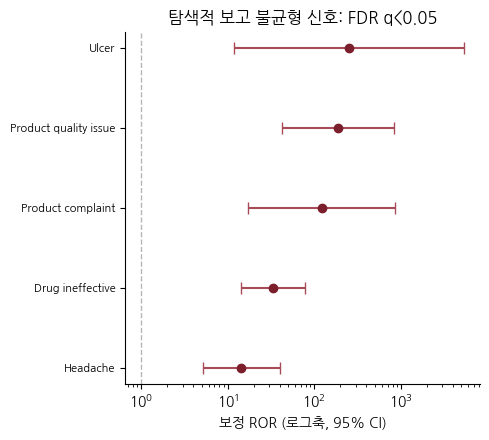

저장 위치: /content/faers_acetaminophen_aspirin_caffeine/07_ROR_Forest_plot.png


In [14]:

#FDR 유의 반응 Forest plot

plot_df = significant_signal_df.copy()

if len(plot_df) == 0:
    print(
        "FDR q<0.05인 반응이 없어 Forest plot을 생성하지 않습니다."
    )
else:
    plot_df = (
        plot_df
        .sort_values("보정_ROR")
        .tail(15)
    )

    fig, ax = plt.subplots(figsize=(5, 4.5))

    y = np.arange(len(plot_df))
    point = plot_df["보정_ROR"].to_numpy()
    lower = plot_df["95CI_하한"].to_numpy()
    upper = plot_df["95CI_상한"].to_numpy()

    x_error = np.vstack([
        point - lower,
        upper - point,
    ])

    ax.errorbar(
        point,
        y,
        xerr=x_error,
        fmt="o",
        color=BURGUNDY,
        ecolor=MID_RED,
        capsize=4,
    )

    ax.axvline(
        1,
        linestyle="--",
        linewidth=1,
        color=GRAY,
    )

    ax.set_xscale("log")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["반응"], fontsize=8)
    ax.set_xlabel("보정 ROR (로그축, 95% CI)")
    ax.set_title("탐색적 보고 불균형 신호: FDR q<0.05")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    forest_path = os.path.join(
        OUTPUT_DIR,
        "07_ROR_Forest_plot.png",
    )

    plt.savefig(
        forest_path,
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close()

    print("저장 위치:", forest_path)


In [15]:

# 위장관 궤양 관련 반응을 묶은 탐색적 Fisher 검정

def is_gi_ulcer_related(value):
    exclusions = [
        "decubitus",
        "gingival",
        "keratitis",
        "colitis ulcerative",
    ]

    for term in split_terms(value):
        term_lower = term.lower()

        if (
            "ulcer" in term_lower
            and not any(
                excluded in term_lower
                for excluded in exclusions
            )
        ):
            return True

    return False

target_ulcer = (
    target_df["reactions"]
    .apply(is_gi_ulcer_related)
)

other_ulcer = (
    other_df["reactions"]
    .apply(is_gi_ulcer_related)
)

a = int(target_ulcer.sum())
b = len(target_df) - a
c = int(other_ulcer.sum())
d = len(other_df) - c

exact_or, p_value = stats.fisher_exact([[a, b], [c, d]])
corrected_or, ci_low, ci_high = corrected_or_ci(a, b, c, d)

gi_ulcer_result = pd.DataFrame([{
    "대상_궤양관련_보고수": a,
    "대상_전체": len(target_df),
    "대상_비율": a / len(target_df),
    "비교군_궤양관련_보고수": c,
    "비교군_전체": len(other_df),
    "비교군_비율": c / len(other_df),
    "Fisher_exact_OR": exact_or,
    "보정_OR": corrected_or,
    "95CI_하한": ci_low,
    "95CI_상한": ci_high,
    "p_value": p_value,
}])

display(
    gi_ulcer_result.style.format({
        "대상_비율": "{:.2%}",
        "비교군_비율": "{:.2%}",
        "Fisher_exact_OR": "{:.2f}",
        "보정_OR": "{:.2f}",
        "95CI_하한": "{:.2f}",
        "95CI_상한": "{:.2f}",
        "p_value": "{:.6f}",
    })
)

gi_ulcer_result.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "위장관궤양_탐색적_Fisher검정.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

print(
    "이 분석은 탐색적 보고 신호입니다. "
    "OR을 실제 위험배수로 해석하면 안 됩니다."
)


,대상_궤양관련_보고수,대상_전체,대상_비율,비교군_궤양관련_보고수,비교군_전체,비교군_비율,Fisher_exact_OR,보정_OR,95CI_하한,95CI_상한,p_value
0,3,26,11.54%,7,1222,0.57%,22.64,24.14,6.37,91.52,0.000876


이 분석은 탐색적 보고 신호입니다. OR을 실제 위험배수로 해석하면 안 됩니다.


In [16]:
summary_rows = []

for label, count, pct in zip(
    severity_labels,
    severity_counts,
    severity_pct,
):
    summary_rows.append([
        "중증도",
        label,
        count,
        pct / 100,
    ])

for label, count, pct in zip(
    age_labels_ko,
    age_counts.tolist(),
    age_pct.tolist(),
):
    summary_rows.append([
        "연령대",
        label.replace("\n", " "),
        int(count),
        pct / 100,
    ])

for label, count, pct in zip(
    sex_labels_ko,
    sex_counts.tolist(),
    sex_pct.tolist(),
):
    summary_rows.append([
        "성별",
        label,
        int(count),
        pct / 100,
    ])

for label, count, pct in zip(
    drug_labels_ko,
    drug_counts.tolist(),
    drug_pct.tolist(),
):
    summary_rows.append([
        "병용약물 수",
        label.replace("\n", " "),
        int(count),
        pct / 100,
    ])

for label, count in indication_top5:
    summary_rows.append([
        "적응증 Top5",
        label,
        int(count),
        count / N,
    ])

for label, count in reaction_top8:
    summary_rows.append([
        "보고 반응 Top8",
        label,
        int(count),
        count / N,
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "분석구분",
        "항목",
        "건수",
        "전체대비_비율",
    ],
)

summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "6패널_집계결과.csv"),
    index=False,
    encoding="utf-8-sig",
)

target_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "아세트아미노펜_아스피린_카페인_대상보고.csv",
    ),
    index=False,
    encoding="utf-8-sig",
)

display(summary_df)


,분석구분,항목,건수,전체대비_비율
0,중증도,중대,7,0.269231
1,중증도,사망,0,0.000000
2,중증도,입원,3,0.115385
3,중증도,생명위협,0,0.000000
4,중증도,후유장애,0,0.000000
5,연령대,영유아 (0–2),0,0.000000
6,연령대,아동 (3–12),0,0.000000
7,연령대,청소년 (13–18),0,0.000000
8,연령대,성인 (19–40),1,0.038462
9,연령대,중년 (41–65),2,0.076923
